In [170]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap
import optuna
import joblib
import json

In [171]:

df=pd.read_csv('Food_Delivery_Times.csv');
print(df.describe());

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count        1000.000000  
mean           56.732000  
std            22.070915  
min             8.000000  
25%            41.000000  
50%            55.500000  
75%            71.000000  
max           153.000000  


In [172]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('darkgrid')
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['figure.figsize']=(10,6)
matplotlib.rcParams['figure.facecolor']='#00000000'

In [173]:
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [174]:
fig=px.histogram(df,x='Distance_km',marginal='box',nbins=21,title='Distribution of Distance')
fig.update_layout(bargap=0.1)
fig.show()

In [175]:
fig=px.histogram(df,x='Preparation_Time_min',marginal='box',nbins=25,title='Distribution of prep time')
fig.update_layout(bargap=0.1)
fig.show()

In [176]:
fig=px.histogram(df,x='Courier_Experience_yrs',marginal='box',nbins=10,title='Distribution of prep time')
fig.update_layout(bargap=0.1)
fig.show()

In [177]:
fig=px.histogram(df,x='Delivery_Time_min',marginal='box',nbins=146,title='Distribution of prep time')
fig.update_layout(bargap=0.1)
fig.show()

In [178]:
ndf=df.drop("Order_ID", axis=1)
ndf


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [179]:
ndf.isnull().sum()


Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [180]:
ndf[ndf.isnull().any(axis=1)]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
6,9.52,Clear,Low,NaN,Bike,12,1.0,49
14,2.80,Clear,High,Morning,Scooter,10,NaN,33
24,11.20,Clear,Medium,Morning,Bike,23,NaN,73
42,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,4.17,NaN,Low,Evening,Scooter,5,1.0,22
...,...,...,...,...,...,...,...,...
974,11.68,Clear,NaN,Afternoon,Scooter,25,7.0,70
976,8.96,Snowy,NaN,Morning,Car,6,5.0,51
987,7.44,Rainy,Low,Evening,Bike,27,NaN,53
988,14.39,Rainy,Medium,Morning,Scooter,6,NaN,50


In [181]:
ndf[ndf['Weather'].isnull()]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
42,0.99,NaN,Medium,Evening,Bike,15,NaN,32
71,4.17,NaN,Low,Evening,Scooter,5,1.0,22
153,2.78,NaN,High,Afternoon,Scooter,9,0.0,41
167,4.15,NaN,Medium,Morning,Car,17,8.0,46
168,16.80,NaN,High,Morning,Car,19,4.0,85
203,1.06,NaN,Low,Afternoon,Scooter,19,6.0,21
225,14.77,NaN,High,Morning,Scooter,11,6.0,67
230,8.27,NaN,High,Afternoon,Scooter,13,5.0,58
257,6.24,NaN,Medium,Evening,Bike,15,3.0,52
281,11.52,NaN,Medium,Morning,Scooter,25,2.0,58


In [182]:
ndf['Weather'] = ndf['Weather'].fillna('Unknown')
ndf

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [183]:
ndf[ndf['Weather'].isnull()]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


In [184]:
ndf.isnull().sum()

Distance_km                0
Weather                    0
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [185]:
ndf

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [186]:
ndf[ndf['Traffic_Level'].isnull()]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
85,10.65,Clear,NaN,Afternoon,Scooter,23,8.0,58
119,2.98,Foggy,NaN,Night,Bike,11,2.0,27
190,17.54,Clear,NaN,Morning,Car,16,8.0,54
199,7.49,Clear,NaN,Morning,Scooter,13,9.0,45
262,8.84,Clear,NaN,Morning,Bike,26,0.0,57
294,9.44,Rainy,NaN,Evening,Scooter,28,8.0,63
319,13.21,Clear,NaN,Morning,Scooter,12,4.0,63
332,1.80,Clear,NaN,Night,Bike,14,1.0,28
376,19.40,Snowy,NaN,Afternoon,Scooter,23,9.0,92
379,18.46,Clear,NaN,NaN,Scooter,29,1.0,153


In [187]:
ndf['Traffic_Level']= ndf['Traffic_Level'].fillna('Unknown')
ndf[ndf['Traffic_Level'].isnull()]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


In [188]:
ndf.isnull().sum()

Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [189]:
ndf['Time_of_Day']=ndf['Time_of_Day'].fillna('Unknown')
ndf[ndf['Time_of_Day'].isnull()]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


In [190]:
ndf.isnull().sum()

Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [191]:
ndf['Courier_Experience_yrs'] = (
    ndf['Courier_Experience_yrs']
    .fillna(ndf['Courier_Experience_yrs'].median())
)
ndf.isnull().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [192]:
ndf

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [193]:
ndf['Weather'].unique()

array(['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', 'Unknown'],
      dtype=object)

In [194]:
fig=px.histogram(ndf,x='Delivery_Time_min',marginal='box',color='Weather',color_discrete_sequence=['red','orange','black','blue','green','grey'],nbins=146, title='weather vs delivery time')
fig.update_layout(bargap=0.1)
fig.show()

In [195]:
fig=px.scatter(df,x='Delivery_Time_min',y='Weather',color='Weather',opacity=0.6,hover_data=['Time_of_Day','Traffic_Level'],title='Delivery Time vs Weather')
fig.update_traces(marker_size=5)
fig.show()

In [196]:
ndf 

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [197]:
ndf['Time_of_Day'].unique()
ndf['Time_of_Day'].count()

np.int64(1000)

In [198]:
fig=px.histogram(ndf,x='Delivery_Time_min',marginal='box',color='Time_of_Day',color_discrete_sequence=['red','orange','black','blue','green'],nbins=146, title='time of day vs delivery time')
fig.update_layout(bargap=0.1)
fig.show()

In [199]:
ndf

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [200]:
ndf['Vehicle_Type'].unique()

array(['Scooter', 'Bike', 'Car'], dtype=object)

In [201]:
fig=px.histogram(ndf,x='Delivery_Time_min',marginal='box',color='Vehicle_Type',color_discrete_sequence=['orange','blue','green'],nbins=146, title='vehicle_type vs delivery time')
fig.update_layout(bargap=0.1)
fig.show()

In [202]:
ndf['Traffic_Level'].unique()

array(['Low', 'Medium', 'High', 'Unknown'], dtype=object)

In [203]:
fig=px.histogram(ndf,x='Delivery_Time_min',marginal='box',color='Traffic_Level',color_discrete_sequence=['orange','blue','green','black'],nbins=146, title='Traffic level vs delivery time')
fig.update_layout(bargap=0.1)
fig.show()

In [204]:
ndf

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [205]:
ndf['Courier_Experience_yrs'].unique()

array([1., 2., 5., 9., 6., 4., 7., 3., 8., 0.])

In [206]:
fig = px.box(
    ndf,
    x='Courier_Experience_yrs',
    y='Delivery_Time_min',
    points='outliers',
    title='Courier Experience vs Delivery Time'
)
fig.show()

In [207]:
fig = px.violin(
    ndf,
    x='Courier_Experience_yrs',
    y='Delivery_Time_min',
    box=True
)
fig.show()

In [208]:
ndf

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [209]:
fig=px.scatter(df,x='Delivery_Time_min',y='Distance_km',color='Weather',opacity=0.6,hover_data=['Time_of_Day','Traffic_Level','Vehicle_Type','Preparation_Time_min'],title='Delivery Time vs distance')
fig.update_traces(marker_size=5)
fig.show()

In [210]:
fig=px.scatter(df,x='Delivery_Time_min',y='Preparation_Time_min',color='Weather',opacity=0.6,hover_data=['Time_of_Day','Traffic_Level','Vehicle_Type','Distance_km'],title='Delivery Time vs distance')
fig.update_traces(marker_size=5)
fig.show()

In [211]:
num_df = ndf.select_dtypes(include='number')
print(num_df.corr())

                        Distance_km  Preparation_Time_min  \
Distance_km                1.000000             -0.009037   
Preparation_Time_min      -0.009037              1.000000   
Courier_Experience_yrs    -0.007534             -0.030842   
Delivery_Time_min          0.780998              0.307350   

                        Courier_Experience_yrs  Delivery_Time_min  
Distance_km                          -0.007534           0.780998  
Preparation_Time_min                 -0.030842           0.307350  
Courier_Experience_yrs                1.000000          -0.089111  
Delivery_Time_min                    -0.089111           1.000000  


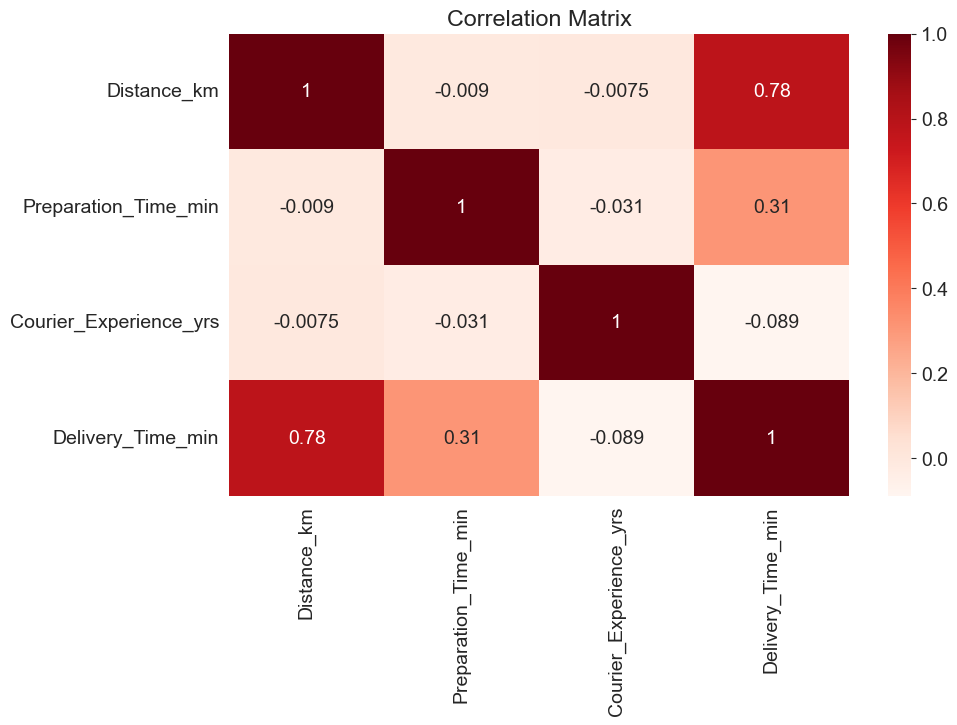

In [212]:
sns.heatmap(num_df.corr(),cmap='Reds',annot=True)
plt.title('Correlation Matrix');

In [213]:
ndf['Weather']

0      Windy
1      Clear
2      Foggy
3      Rainy
4      Clear
       ...  
995    Clear
996    Rainy
997    Snowy
998    Clear
999    Foggy
Name: Weather, Length: 1000, dtype: object

In [214]:
encoders = {}
cat_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"]
for col in cat_cols:
    le = LabelEncoder()
    ndf[col] = le.fit_transform(ndf[col].astype(str))
    encoders[col] = le

In [215]:
encoders["Weather"].classes_

array(['Clear', 'Foggy', 'Rainy', 'Snowy', 'Unknown', 'Windy'],
      dtype=object)

In [216]:
ndf['Traffic_Level']

0      1
1      2
2      1
3      2
4      1
      ..
995    0
996    1
997    0
998    1
999    1
Name: Traffic_Level, Length: 1000, dtype: int64

In [217]:
ndf["distance_sq"] = ndf["Distance_km"] ** 2
ndf["dist_x_prep"] = ndf["Distance_km"] * ndf["Preparation_Time_min"]
ndf["traffic_x_dist"] = ndf["Traffic_Level"] * ndf["Distance_km"]

# Drop courier experience — near-zero correlation, adds noise
ndf.drop(columns=["Courier_Experience_yrs"], inplace=True)

In [218]:
X = ndf.drop(columns=["Delivery_Time_min"])
y = ndf["Delivery_Time_min"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [219]:
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,       # L1 regularization against overfitting
    reg_lambda=1.0,      # L2 regularization
    random_state=42,
    early_stopping_rounds=30,
    eval_metric="rmse"
)

X_tr, X_val, y_tr, y_val = train_test_split(X_train_sc, y_train, test_size=0.15, random_state=42)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=50)

[0]	validation_0-rmse:20.97684
[50]	validation_0-rmse:10.89680
[100]	validation_0-rmse:10.72095
[110]	validation_0-rmse:10.74585


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [220]:
def objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 3, 7),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("alpha", 0.0, 1.0),
        "reg_lambda":       trial.suggest_float("lambda", 0.5, 5.0),
        "n_estimators": 300,
        "random_state": 42
    }
    m = xgb.XGBRegressor(**params)
    scores = cross_val_score(m, X_train_sc, y_train, cv=5,
                             scoring="neg_root_mean_squared_error")
    return -scores.mean()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
best_params = study.best_params

[I 2026-06-13 17:06:26,632] A new study created in memory with name: no-name-eb9a066f-8e79-4052-9e7d-1ce5423184ca
[I 2026-06-13 17:06:28,494] Trial 0 finished with value: 12.415087890625 and parameters: {'max_depth': 7, 'lr': 0.03555421628072897, 'subsample': 0.6291728571137797, 'colsample': 0.9715447989773651, 'alpha': 0.3996134866340223, 'lambda': 2.026142875037606}. Best is trial 0 with value: 12.415087890625.
[I 2026-06-13 17:06:29,224] Trial 1 finished with value: 12.809500312805175 and parameters: {'max_depth': 6, 'lr': 0.10952476849017491, 'subsample': 0.8940854332405774, 'colsample': 0.8033197846419103, 'alpha': 0.3110398233430588, 'lambda': 2.3802590785898996}. Best is trial 0 with value: 12.415087890625.
[I 2026-06-13 17:06:29,528] Trial 2 finished with value: 11.696537208557128 and parameters: {'max_depth': 3, 'lr': 0.03334709750863364, 'subsample': 0.8742730313838869, 'colsample': 0.9499182820275298, 'alpha': 0.30869305279535153, 'lambda': 2.0564797825798697}. Best is trial

RMSE: 10.12 min  |  MAE: 7.15 min  |  R²: 0.772


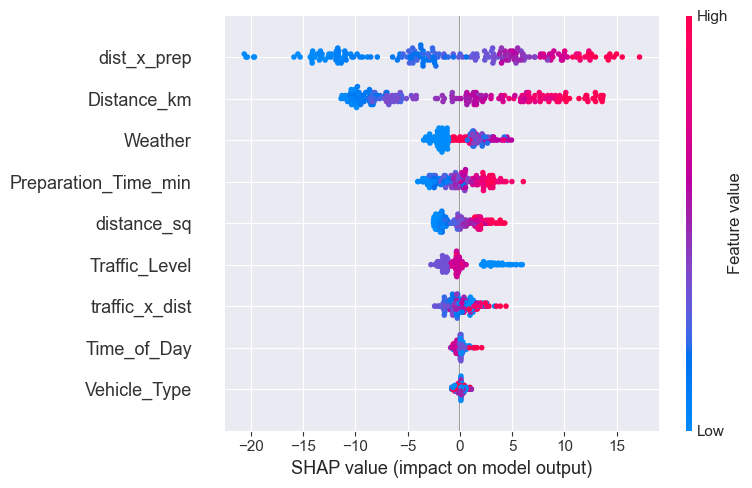

In [221]:
preds = model.predict(X_test_sc)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)

print(f"RMSE: {rmse:.2f} min  |  MAE: {mae:.2f} min  |  R²: {r2:.3f}")

# SHAP for interpretability
explainer = shap.Explainer(model)
shap_vals = explainer(X_test_sc)
shap.summary_plot(shap_vals, X_test, feature_names=X.columns.tolist())

In [222]:
joblib.dump(scaler, "delivery_scaler.pkl")
joblib.dump(model,  "delivery_model.pkl")
json.dump(X.columns.tolist(), open("feature_columns.json", "w"))

print("✅ Saved: delivery_model.pkl, delivery_scaler.pkl, feature_columns.json")

✅ Saved: delivery_model.pkl, delivery_scaler.pkl, feature_columns.json


In [223]:
import os
print(os.getcwd())          # shows you the folder they saved to
print(os.listdir("."))      # should show the 3 files in that folder

c:\Users\KIIT\Desktop\comp\Sikit learn\delivery time prediction
['backend', 'delivery_model.pkl', 'delivery_scaler.pkl', 'feature_columns.json', 'Food_Delivery_Times.csv', 'Timeprediction.ipynb']
